In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error, r2_score

from catboost import CatBoostRegressor

In [2]:
data = pd.read_csv(r"C:\Users\saura\OneDrive\Desktop\HackerEarth\dataset\train.csv")
test_data = pd.read_csv(r'C:\Users\saura\OneDrive\Desktop\HackerEarth\dataset\test.csv')

data.columns = data.columns.str.lower()
test_data.columns = test_data.columns.str.lower()

test_index = test_data['id']

data.drop(columns=['id' ], axis=1, inplace=True)
test_data.drop(columns=['id'], axis=1, inplace=True)

data.head()

,electricity_kwh_per_month,natural_gas_therms_per_month,vehicle_miles_per_month,house_area_sqft,water_usage_liters_per_day,public_transport_usage_per_week,household_size,home_insulation_quality,meat_consumption_kg_per_week,laundry_loads_per_week,recycles_regularly,composts_organic_waste,uses_solar_panels,energy_efficient_appliances,heating_type,diet_type,owns_pet,smart_thermostat_installed,carbon_footprint
0,759.70,55.95,944.55,2422.07,541.27,1,3,2,4.23,9,1.0,0.0,0,1.0,gas,vegetarian,1,NaN,830.10
1,387.06,70.59,1280.85,1995.3,280.39,1,2,1,3.27,8,0.0,0.0,0,0.0,electric,vegetarian,0,0.0,963.08
2,594.25,29.14,1005.72,2673.55,416.14,0,2,3,2.87,3,0.0,1.0,0,1.0,electric,omnivore,1,1.0,840.11
3,503.76,74.68,1049.46,2994.28,530.13,0,5,1,3.22,9,1.0,0.0,0,0.0,electric,omnivore,1,0.0,1252.42
4,549.54,-77.00,756.49,2549.57,604.10,5,4,4,2.92,2,1.0,0.0,0,1.0,electric,vegetarian,0,1.0,580.74


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14000 entries, 0 to 13999
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   electricity_kwh_per_month        14000 non-null  float64
 1   natural_gas_therms_per_month     14000 non-null  float64
 2   vehicle_miles_per_month          14000 non-null  float64
 3   house_area_sqft                  14000 non-null  object 
 4   water_usage_liters_per_day       14000 non-null  float64
 5   public_transport_usage_per_week  14000 non-null  int64  
 6   household_size                   14000 non-null  object 
 7   home_insulation_quality          14000 non-null  int64  
 8   meat_consumption_kg_per_week     14000 non-null  float64
 9   laundry_loads_per_week           14000 non-null  int64  
 10  recycles_regularly               13590 non-null  float64
 11  composts_organic_waste           13610 non-null  float64
 12  uses_solar_panels 

In [4]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   electricity_kwh_per_month        6000 non-null   float64
 1   natural_gas_therms_per_month     6000 non-null   float64
 2   vehicle_miles_per_month          6000 non-null   float64
 3   house_area_sqft                  6000 non-null   object 
 4   water_usage_liters_per_day       6000 non-null   float64
 5   public_transport_usage_per_week  6000 non-null   int64  
 6   household_size                   6000 non-null   object 
 7   home_insulation_quality          6000 non-null   int64  
 8   meat_consumption_kg_per_week     6000 non-null   float64
 9   laundry_loads_per_week           6000 non-null   int64  
 10  recycles_regularly               5821 non-null   float64
 11  composts_organic_waste           5800 non-null   float64
 12  uses_solar_panels   

In [5]:
data.isna().sum()

electricity_kwh_per_month            0
natural_gas_therms_per_month         0
vehicle_miles_per_month              0
house_area_sqft                      0
water_usage_liters_per_day           0
public_transport_usage_per_week      0
household_size                       0
home_insulation_quality              0
meat_consumption_kg_per_week         0
laundry_loads_per_week               0
recycles_regularly                 410
composts_organic_waste             390
uses_solar_panels                    0
energy_efficient_appliances        431
heating_type                         0
diet_type                            0
owns_pet                             0
smart_thermostat_installed         416
carbon_footprint                     0
dtype: int64

In [6]:
data['household_size'] = pd.to_numeric(data['household_size'], errors='coerce')
data_non_convertible_count = data['household_size'].isna().sum()

print(f"Number of rows that couldn't be converted to numeric in train data: {data_non_convertible_count}")

test_data['household_size'] = pd.to_numeric(test_data['household_size'], errors='coerce')
test_data_non_convertible_count = test_data['household_size'].isna().sum()

print(f"Number of rows that couldn't be converted to numeric in test data: {test_data_non_convertible_count}")

Number of rows that couldn't be converted to numeric in train data: 430
Number of rows that couldn't be converted to numeric in test data: 160


In [7]:
data['house_area_sqft'] = pd.to_numeric(data['house_area_sqft'], errors='coerce')
data_non_convertible_count = data['house_area_sqft'].isna().sum()

print(f"Number of rows that couldn't be converted to numeric in train data: {data_non_convertible_count}")

test_data['house_area_sqft'] = pd.to_numeric(test_data['house_area_sqft'], errors='coerce')
test_data_non_convertible_count = test_data['house_area_sqft'].isna().sum()

print(f"Number of rows that couldn't be converted to numeric in test data: {test_data_non_convertible_count}")

Number of rows that couldn't be converted to numeric in train data: 419
Number of rows that couldn't be converted to numeric in test data: 170


In [8]:
valid_categories = ['electric', 'gas', 'none']
data['heating_type'] = data['heating_type'].apply(lambda x: x if x in valid_categories else 'NA')
test_data['heating_type'] = test_data['heating_type'].apply(lambda x: x if x in valid_categories else 'NA')

In [9]:
data.isna().sum()

electricity_kwh_per_month            0
natural_gas_therms_per_month         0
vehicle_miles_per_month              0
house_area_sqft                    419
water_usage_liters_per_day           0
public_transport_usage_per_week      0
household_size                     430
home_insulation_quality              0
meat_consumption_kg_per_week         0
laundry_loads_per_week               0
recycles_regularly                 410
composts_organic_waste             390
uses_solar_panels                    0
energy_efficient_appliances        431
heating_type                         0
diet_type                            0
owns_pet                             0
smart_thermostat_installed         416
carbon_footprint                     0
dtype: int64

In [10]:
test_data.isna().sum()

electricity_kwh_per_month            0
natural_gas_therms_per_month         0
vehicle_miles_per_month              0
house_area_sqft                    170
water_usage_liters_per_day           0
public_transport_usage_per_week      0
household_size                     160
home_insulation_quality              0
meat_consumption_kg_per_week         0
laundry_loads_per_week               0
recycles_regularly                 179
composts_organic_waste             200
uses_solar_panels                    0
energy_efficient_appliances        162
heating_type                         0
diet_type                            0
owns_pet                             0
smart_thermostat_installed         174
dtype: int64

In [11]:
print("Original training data shape was: ", data.shape)
data = data.loc[data['electricity_kwh_per_month']>0].reset_index(drop=True)
data = data.loc[data['natural_gas_therms_per_month']>=0].reset_index(drop=True)
data = data.loc[data['vehicle_miles_per_month']>=0].reset_index(drop=True)
data = data.loc[data['water_usage_liters_per_day']>0].reset_index(drop=True)
data = data.loc[data['public_transport_usage_per_week']>=0].reset_index(drop=True)
data = data.loc[data['home_insulation_quality']>=0].reset_index(drop=True)
data = data.dropna(subset=['house_area_sqft', 'household_size']).reset_index(drop=True)

data['carbon_footprint'] = np.log1p(data['carbon_footprint'])
print("Modified training data shape after dropping irrelevant rows is: ", data.shape)

Original training data shape was:  (14000, 19)
Modified training data shape after dropping irrelevant rows is:  (11902, 19)


In [12]:
# Since home_insulation_quality is measured on a scale from 0 (poor) to 7 (excellent).
index1 = data.loc[data['home_insulation_quality']>=8].index
data.loc[index1, 'home_insulation_quality'] = 7

index2 = test_data.loc[test_data['home_insulation_quality']>=8].index
test_data.loc[index2, 'home_insulation_quality'] = 7

test_data['home_insulation_quality'] = test_data['home_insulation_quality'].apply(lambda x: int(data['home_insulation_quality'].median()) if x < 0 else x)

In [13]:
global_electricity_per_month = data['electricity_kwh_per_month'].mean()
test_data['electricity_kwh_per_month'] = test_data.apply(
    lambda row: global_electricity_per_month if row['electricity_kwh_per_month'] < 0 else row['electricity_kwh_per_month'], 
    axis=1)

global_gas_per_month = data['natural_gas_therms_per_month'].mean()
test_data['natural_gas_therms_per_month'] = test_data.apply(
    lambda row: global_gas_per_month if row['natural_gas_therms_per_month'] < 0 else row['natural_gas_therms_per_month'], 
    axis=1)

global_miles_per_month = data['vehicle_miles_per_month'].median()
test_data['vehicle_miles_per_month'] = test_data.apply(
    lambda row: global_miles_per_month if row['vehicle_miles_per_month'] < 0 else row['vehicle_miles_per_month'], 
    axis=1)

global_water_per_day = data['water_usage_liters_per_day'].median()
test_data['water_usage_liters_per_day'] = test_data.apply(
    lambda row: global_water_per_day if row['water_usage_liters_per_day'] < 0 else row['water_usage_liters_per_day'], 
    axis=1)

global_pub_transport_per_week = data['public_transport_usage_per_week'].median()
test_data['public_transport_usage_per_week'] = test_data.apply(
    lambda row: global_pub_transport_per_week if row['public_transport_usage_per_week'] < 0 else row['public_transport_usage_per_week'], 
    axis=1)

In [14]:
test_data['house_area_sqft'] = test_data['house_area_sqft'].fillna(data['house_area_sqft'].mean())
test_data['household_size'] = test_data['household_size'].fillna(data['household_size'].median())

data['recycles_regularly'] = data['recycles_regularly'].fillna(-1).astype(str)
test_data['recycles_regularly'] = test_data['recycles_regularly'].fillna(-1).astype(str)

data['composts_organic_waste'] = data['composts_organic_waste'].fillna(-1).astype(str)
test_data['composts_organic_waste'] = test_data['composts_organic_waste'].fillna(-1).astype(str)

data['energy_efficient_appliances'] = data['energy_efficient_appliances'].fillna(-1).astype(str)
test_data['energy_efficient_appliances'] = test_data['energy_efficient_appliances'].fillna(-1).astype(str)

data['smart_thermostat_installed'] = data['smart_thermostat_installed'].fillna(-1).astype(str)
test_data['smart_thermostat_installed'] = test_data['smart_thermostat_installed'].fillna(-1).astype(str)

In [15]:
data.isna().sum()

electricity_kwh_per_month          0
natural_gas_therms_per_month       0
vehicle_miles_per_month            0
house_area_sqft                    0
water_usage_liters_per_day         0
public_transport_usage_per_week    0
household_size                     0
home_insulation_quality            0
meat_consumption_kg_per_week       0
laundry_loads_per_week             0
recycles_regularly                 0
composts_organic_waste             0
uses_solar_panels                  0
energy_efficient_appliances        0
heating_type                       0
diet_type                          0
owns_pet                           0
smart_thermostat_installed         0
carbon_footprint                   0
dtype: int64

In [16]:
test_data.isna().sum()

electricity_kwh_per_month          0
natural_gas_therms_per_month       0
vehicle_miles_per_month            0
house_area_sqft                    0
water_usage_liters_per_day         0
public_transport_usage_per_week    0
household_size                     0
home_insulation_quality            0
meat_consumption_kg_per_week       0
laundry_loads_per_week             0
recycles_regularly                 0
composts_organic_waste             0
uses_solar_panels                  0
energy_efficient_appliances        0
heating_type                       0
diet_type                          0
owns_pet                           0
smart_thermostat_installed         0
dtype: int64

In [17]:
categorical_cols = ['home_insulation_quality', 'recycles_regularly', 'composts_organic_waste', 'uses_solar_panels', 'energy_efficient_appliances',
                    'heating_type', 'diet_type', 'owns_pet', 'smart_thermostat_installed']

for col in categorical_cols:
    data[col] = data[col].astype('category')
    test_data[col] = test_data[col].astype('category')

In [ ]:
rmse_errcat = []
r2_errcat = []
y_pred_totcat = []

X = data.drop(columns=['carbon_footprint'])
y = data['carbon_footprint']

fold = KFold(n_splits=10, shuffle=True, random_state=42)

for fold_num, (train_ind, test_ind) in enumerate(fold.split(X),1):
    X_train, X_test = X.loc[train_ind], X.loc[test_ind]
    y_train, y_test = y[train_ind], y[test_ind]
    
    cat = CatBoostRegressor(random_state=42, loss_function='RMSE', cat_features=categorical_cols
        )
    cat.fit(X_train, y_train, verbose=False)
    y_pred = cat.predict(X_test)

    root_mse = root_mean_squared_error(np.expm1(y_test), np.expm1(y_pred))
    r_squarred = r2_score(np.expm1(y_test), np.expm1(y_pred))
    print(f'Fold: {fold_num}, RMSE: {root_mse}')
    print(f'Fold: {fold_num}, R2 Score: {r_squarred}')

    rmse_errcat.append(root_mse)
    r2_errcat.append(r_squarred)
    
    p = cat.predict(test_data)
    y_pred_totcat.append(p)
    

Fold: 1, RMSE: 58.53170542393564
Fold: 1, R2 Score: 0.906041893629149
Fold: 2, RMSE: 52.026777541494155
Fold: 2, R2 Score: 0.9254484849991409
Fold: 3, RMSE: 58.38798177797611
Fold: 3, R2 Score: 0.8989866304246618
Fold: 4, RMSE: 69.28286688541782
Fold: 4, R2 Score: 0.871235721580146
Fold: 5, RMSE: 66.19824138821309
Fold: 5, R2 Score: 0.8815067737342556


In [319]:
print(f"RMSE: {np.mean(rmse_errcat)}, R2: {np.mean(r2_errcat)}")

RMSE: 58.847587178295306, R2: 0.9031559903615813


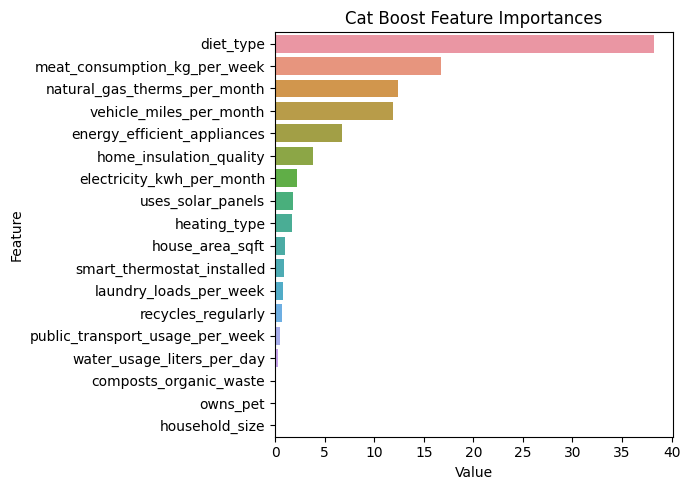

In [320]:
feature_imp = pd.DataFrame(sorted(zip(cat.feature_importances_, X.columns), reverse=True)[:30], columns=['Value','Feature'])
plt.figure(figsize=(7,5))
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False))
plt.title('Cat Boost Feature Importances')
plt.tight_layout()
plt.show()

In [321]:
values = np.expm1(np.mean(y_pred_totcat,0))
values

array([ 642.68817133,  732.58330408, 1045.30382231, ..., 1034.47165077,
        862.96813898,  966.38089337])

In [322]:
final_df = pd.DataFrame({"ID": test_index, "carbon_footprint": values})
final_df

,ID,carbon_footprint
0,0x42e7,642.688171
1,0x1950,732.583304
2,0x20e5,1045.303822
3,0x4378,768.209936
4,0x1301,774.505736
...,...,...
5995,0x1dde,912.972427
5996,0x2c3b,1114.627544
5997,0x4b6,1034.471651
5998,0x4d5a,862.968139


In [323]:
final_df.to_csv('prediction_final.csv', header=True, index=False)